In [8]:
import json

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import pandas as pd


In [3]:
df = pd.read_csv('../data/raw/ec2_cpu_utilization_24ae8d.csv', parse_dates=['timestamp'])
df = df.set_index('timestamp')
df.head()

,value
timestamp,
2014-02-14 14:30:00,0.132
2014-02-14 14:35:00,0.134
2014-02-14 14:40:00,0.134
2014-02-14 14:45:00,0.134
2014-02-14 14:50:00,0.134


In [4]:
df.describe()

,value
count,4032.000000
mean,0.126303
std,0.094813
min,0.066000
25%,0.132000
50%,0.134000
75%,0.134000
max,2.344000


In [5]:
with open('../data/labels/combined_windows.json') as f:
    labels = json.load(f)

windows = labels['realAWSCloudwatch/ec2_cpu_utilization_24ae8d.csv']
windows = [(pd.Timestamp(w[0]), pd.Timestamp(w[1])) for w in windows]
windows

[(Timestamp('2014-02-26 13:45:00'), Timestamp('2014-02-27 06:25:00')),
 (Timestamp('2014-02-27 08:55:00'), Timestamp('2014-02-28 01:35:00'))]

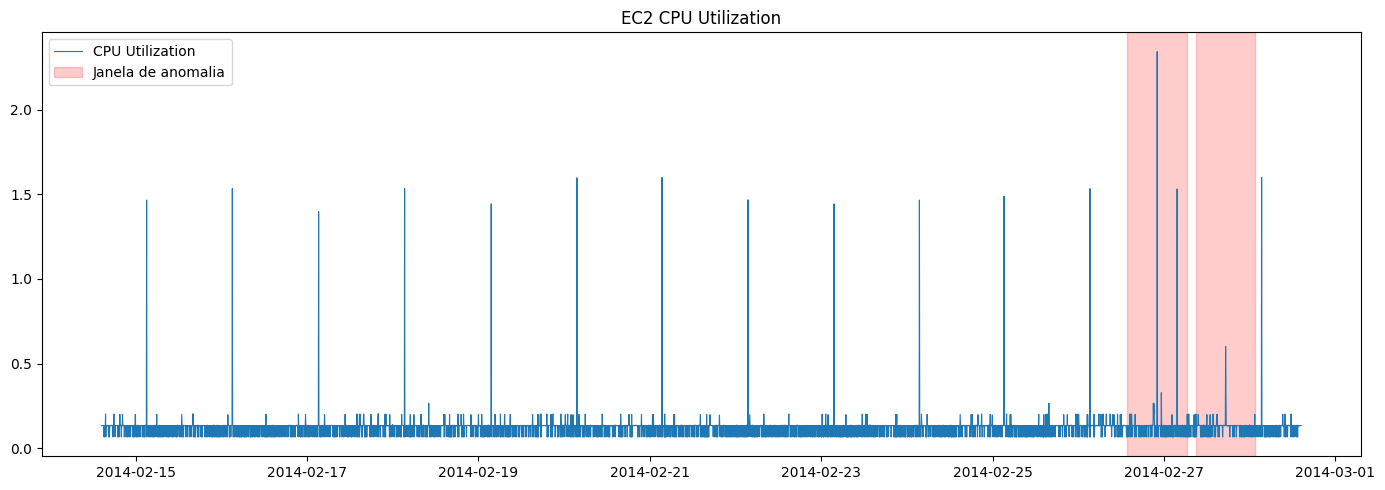

In [6]:
fig, ax = plt.subplots(figsize=(14,5))
ax.plot(df.index, df['value'], linewidth=0.8, label='CPU Utilization')

for i, (start, end) in enumerate(windows):
    ax.axvspan(start, end, color='red', alpha=0.2,
               label='Janela de anomalia' if i == 0 else None)

ax.set_title('EC2 CPU Utilization')
ax.legend()
plt.tight_layout()
plt.show()

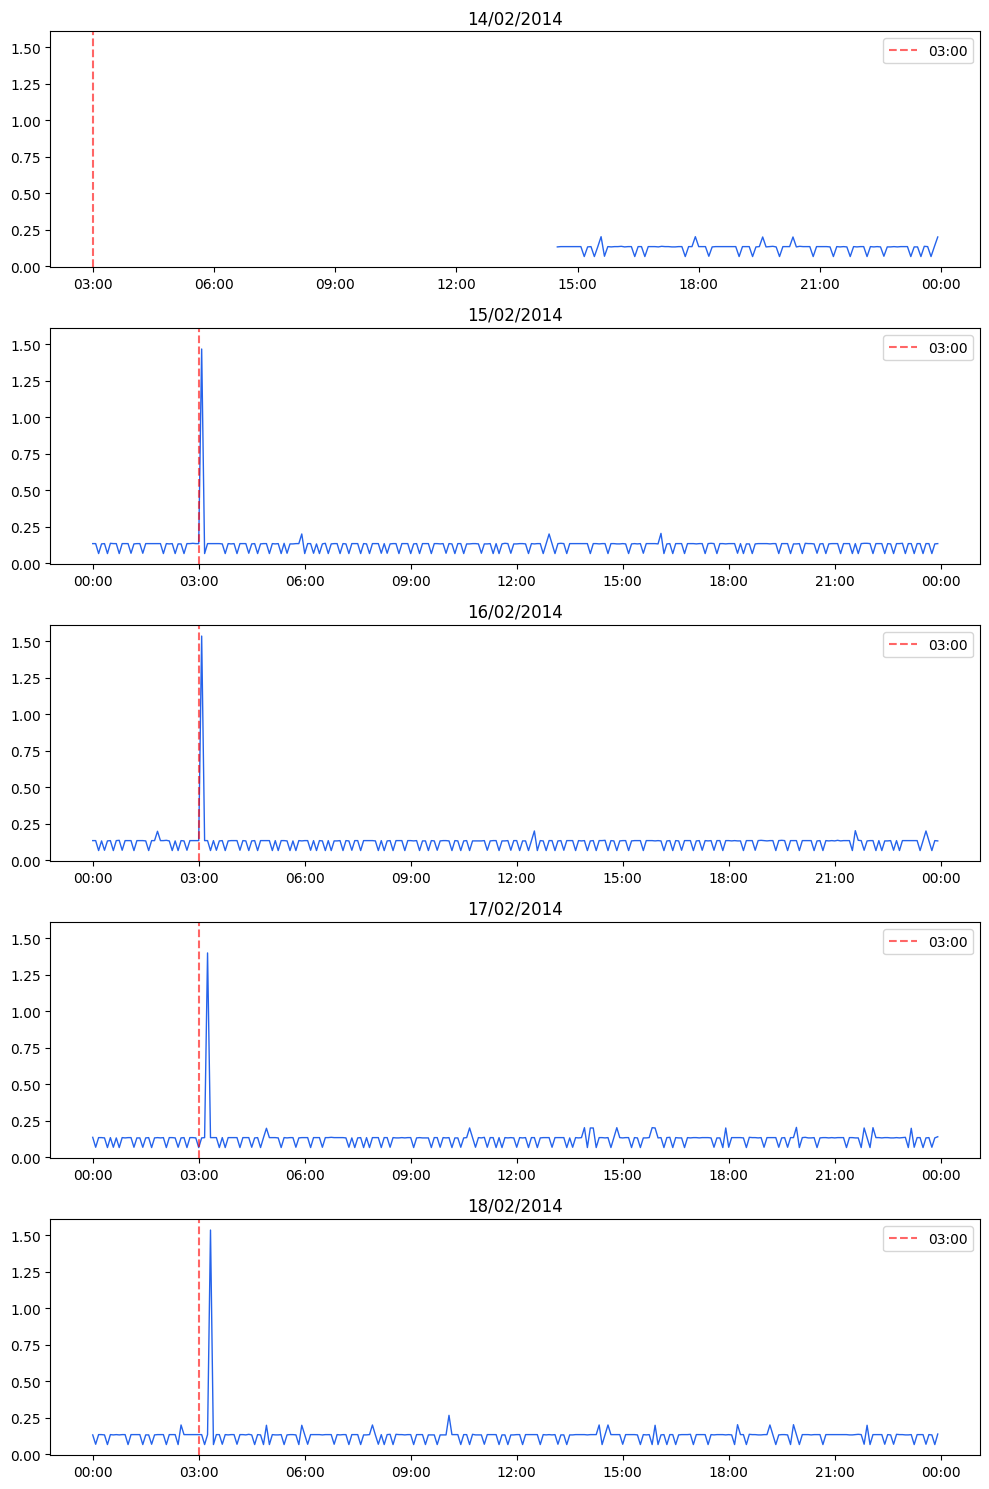

In [9]:
primeiros_dias = sorted(df.index.normalize().unique())[:5]

fig, axes = plt.subplots(len(primeiros_dias), 1, figsize=(10, 3 * len(primeiros_dias)), sharey=True)

for ax, dia in zip(axes, primeiros_dias):
    dados_dia = df[df.index.normalize() == dia]
    ax.plot(dados_dia.index, dados_dia['value'], linewidth=1, color='#2563eb')
    ax.axvline(dia + pd.Timedelta(hours=3), color='red', linestyle='--', alpha=0.6, label='03:00')
    ax.set_title(dia.strftime('%d/%m/%Y'))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
    ax.legend(loc='upper right')

plt.tight_layout()
plt.show()

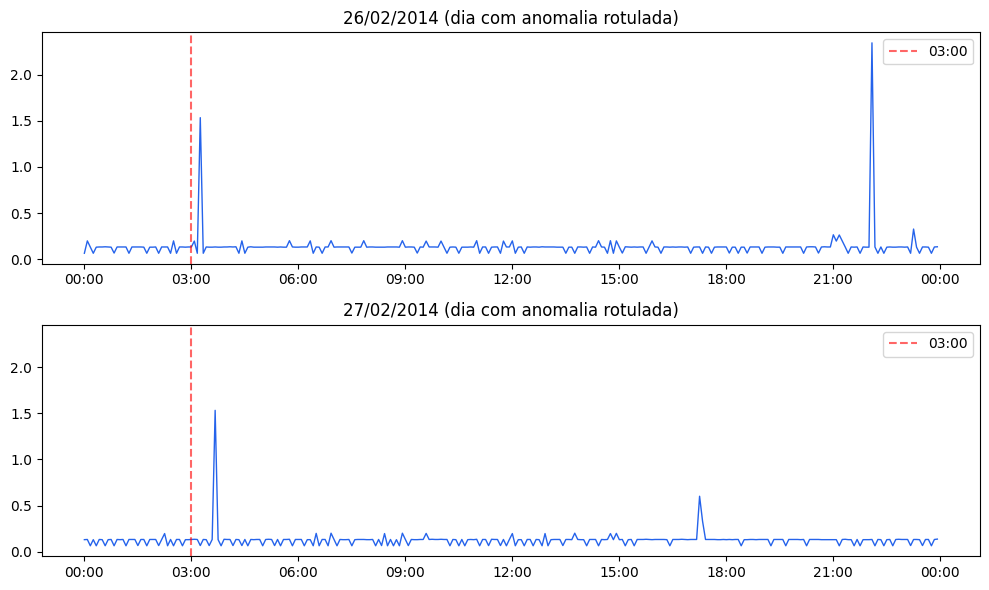

In [ ]:
dias_anomalia = sorted(set(
    d.normalize()
    for start, end in windows
    for d in pd.date_range(start, end, freq='D')
))

fig, axes = plt.subplots(len(dias_anomalia), 1, figsize=(10, 3 * len(dias_anomalia)), sharey=True)

for ax, dia in zip(axes, dias_anomalia):
    dados_dia = df[df.index.normalize() == dia]
    ax.plot(dados_dia.index, dados_dia['value'], linewidth=1, color='#2563eb')
    ax.axvline(dia + pd.Timedelta(hours=3), color='red', linestyle='--', alpha=0.6, label='03:00')

    ax.set_title(dia.strftime('%d/%m/%Y') + ' (dia com anomalia rotulada)')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
    ax.legend(loc='upper right')

plt.tight_layout()
plt.show()